In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns





In [5]:
cus_df=pd.read_csv('customers.csv')
sales_df=pd.read_csv('sales.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'customers.csv'

In [ ]:
cus_df.head()

,order_id,customer_rating
0,1,1
1,2,1
2,3,2
3,4,1
4,5,4


In [ ]:
sales_df.head()

,order_id,date,region,product,category,customer_type,quantity,price,discount,sales
0,1,2024-04-12,East,Laptop,Electronics,Returning,8,590,0.09,4295.20
1,2,2024-12-14,South,Monitor,Accessories,Returning,2,262,0.18,429.68
2,3,2024-09-27,North,Phone,Accessories,New,5,512,0.09,2329.60
3,4,2024-04-16,West,Mouse,Electronics,Returning,1,485,0.09,441.35
4,5,2024-03-12,West,Phone,Electronics,Returning,7,332,0.22,1812.72


In [ ]:
sales_df.shape

(500, 10)

In [ ]:
sales_df.columns

Index(['order_id', 'date', 'region', 'product', 'category', 'customer_type',
       'quantity', 'price', 'discount', 'sales'],
      dtype='object')

In [ ]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       500 non-null    int64  
 1   date           500 non-null    object 
 2   region         500 non-null    object 
 3   product        500 non-null    object 
 4   category       500 non-null    object 
 5   customer_type  500 non-null    object 
 6   quantity       500 non-null    int64  
 7   price          500 non-null    int64  
 8   discount       500 non-null    float64
 9   sales          500 non-null    float64
dtypes: float64(2), int64(3), object(5)
memory usage: 39.2+ KB


In [ ]:
sales_df.customer_type.value_counts()

customer_type
Returning    261
New          239
Name: count, dtype: int64

In [ ]:
sales_df.category.value_counts()

category
Electronics    266
Accessories    234
Name: count, dtype: int64

In [ ]:
sales_df.isnull().sum()

order_id         0
date             0
region           0
product          0
category         0
customer_type    0
quantity         0
price            0
discount         0
sales            0
dtype: int64

In [ ]:
sales_df.duplicated().sum()

np.int64(0)

In [ ]:
sales_df.describe()

,order_id,quantity,price,discount,sales
count,500.000000,500.000000,500.000000,500.00000,500.000000
mean,250.500000,4.968000,768.158000,0.14666,3333.059560
std,144.481833,2.569081,404.010497,0.08612,2693.185995
min,1.000000,1.000000,50.000000,0.00000,67.320000
25%,125.750000,3.000000,432.750000,0.08000,1120.867500
50%,250.500000,5.000000,742.000000,0.15000,2582.805000
75%,375.250000,7.000000,1094.500000,0.22000,4998.030000
max,500.000000,9.000000,1499.000000,0.30000,12700.800000


In [ ]:
cus_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   order_id         500 non-null    int64
 1   customer_rating  500 non-null    int64
dtypes: int64(2)
memory usage: 7.9 KB


In [ ]:
cus_df.describe(include='all')

,order_id,customer_rating
count,500.000000,500.000000
mean,250.500000,2.480000
std,144.481833,1.118975
min,1.000000,1.000000
25%,125.750000,1.000000
50%,250.500000,2.500000
75%,375.250000,3.000000
max,500.000000,4.000000


In [ ]:
df_merged = pd.merge(sales_df, cus_df, on='order_id', how='inner')
df_merged.head(2)

,order_id,date,region,product,category,customer_type,quantity,price,discount,sales,customer_rating
0,1,2024-04-12,East,Laptop,Electronics,Returning,8,590,0.09,4295.20,1
1,2,2024-12-14,South,Monitor,Accessories,Returning,2,262,0.18,429.68,1


In [ ]:
# df_merged = pd.merge(sales_df, cus_df, on='order_id', how='outer')
# df_merged.head(2)

In [ ]:
# EXAMPLE 1: Simple pivot table
print("PIVOT TABLE - Region in rows, Customer type in columns")
print("-" * 50)
pivot1 = pd.pivot_table(
    df_merged, 
    values='sales',           # jo value dikhani hai
    index='region',           # rows me kya hoga
    columns='customer_type',  # columns me kya hoga
    aggfunc='sum'             # kaise calculate karna hai
)
print(pivot1)
print("\n")

# EXAMPLE 2: Multiple values and functions
print("PIVOT TABLE - Multiple calculations")
print("-" * 50)
pivot2 = pd.pivot_table(
    df_merged,
    values=['sales', 'quantity'],
    index='region',
    columns='customer_type',
    aggfunc={'sales': 'sum', 'quantity': 'mean'},
    fill_value=0  # blank jagah 0 likho
)
print(pivot2)
print("\n")

# EXAMPLE 3: Category wise analysis
print("PIVOT TABLE - Category wise sales by region")
print("-" * 50)
pivot3 = pd.pivot_table(
    df_merged,
    values='sales',
    index='category',
    columns='region',
    aggfunc='sum',
    margins=True,  # Total column bhi add karo
    margins_name='Total'
)
print(pivot3)

PIVOT TABLE - Region in rows, Customer type in columns
--------------------------------------------------
customer_type        New  Returning
region                             
East           200553.88  221469.83
North          241039.71  268012.98
South          176204.07  185954.65
West           176139.70  197154.96


PIVOT TABLE - Multiple calculations
--------------------------------------------------
               quantity                sales           
customer_type       New Returning        New  Returning
region                                                 
East           5.596491  5.409836  200553.88  221469.83
North          4.863014  4.858974  241039.71  268012.98
South          4.769231  4.890625  176204.07  185954.65
West           4.526316  4.862069  176139.70  197154.96


PIVOT TABLE - Category wise sales by region
--------------------------------------------------
region            East      North      South       West       Total
category                        

<Axes: xlabel='region'>

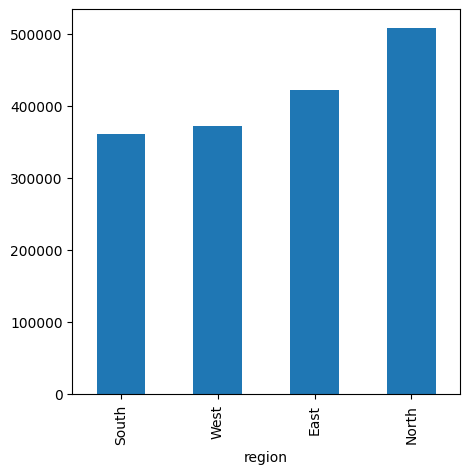

In [ ]:
# region wise in bar chart 


plt.figure(figsize=(5,5))

df_merged.groupby("region")['sales'].sum().sort_values().plot(kind='bar')




Text(0, 0.5, 'sales')

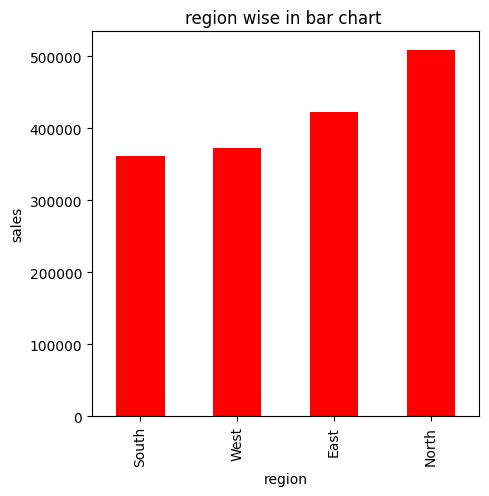

In [ ]:
# region wise in bar chart 


plt.figure(figsize=(5,5))

sales_region=df_merged.groupby("region")['sales'].sum().sort_values()

sales_region.plot(kind='bar',color='red')

plt.title('region wise in bar chart ')
plt.xlabel("region")
plt.ylabel('sales')


customer_type
New          793937.36
Returning    872592.42
Name: sales, dtype: float64

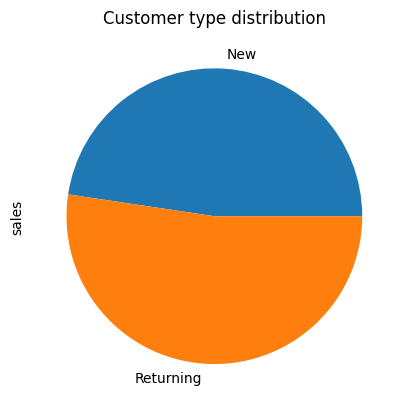

In [ ]:
## 2. PIE CHART - Customer type distribution

c_T_d=df_merged.groupby('customer_type')['sales'].sum()


c_T_d.plot(kind='pie')

plt.title('Customer type distribution')
plt.ylabel('sales')
c_T_d

In [ ]:
df_merged.columns

Index(['date', 'region', 'product', 'category', 'customer_type', 'quantity',
       'price', 'sales', 'customer_rating', 'month', 'color',
       'sales_category'],
      dtype='object')

<Axes: title={'center': 'monthly sales'}, xlabel='monthly', ylabel='sales'>

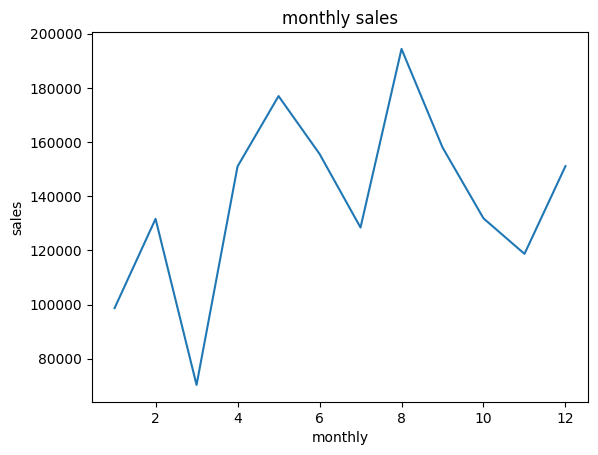

In [ ]:
df_merged['month']=pd.to_datetime(df_merged['date']).dt.month

df_merged.groupby('month')['sales'].sum().plot(kind='line',
                                               title='monthly sales',
                                               xlabel='monthly',
                                               ylabel='sales')


<Axes: ylabel='product'>

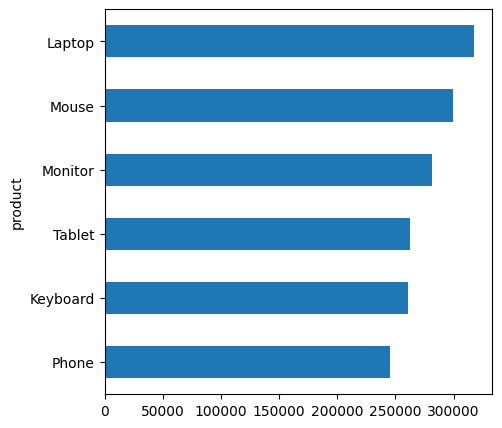

In [ ]:
# 4. HORIZONTAL BAR CHART - Top products by sales
df_merged.groupby('product')['sales'].sum().sort_values().plot(kind='barh',figsize=(5,5))

VISUALIZATIONS USING df_merged


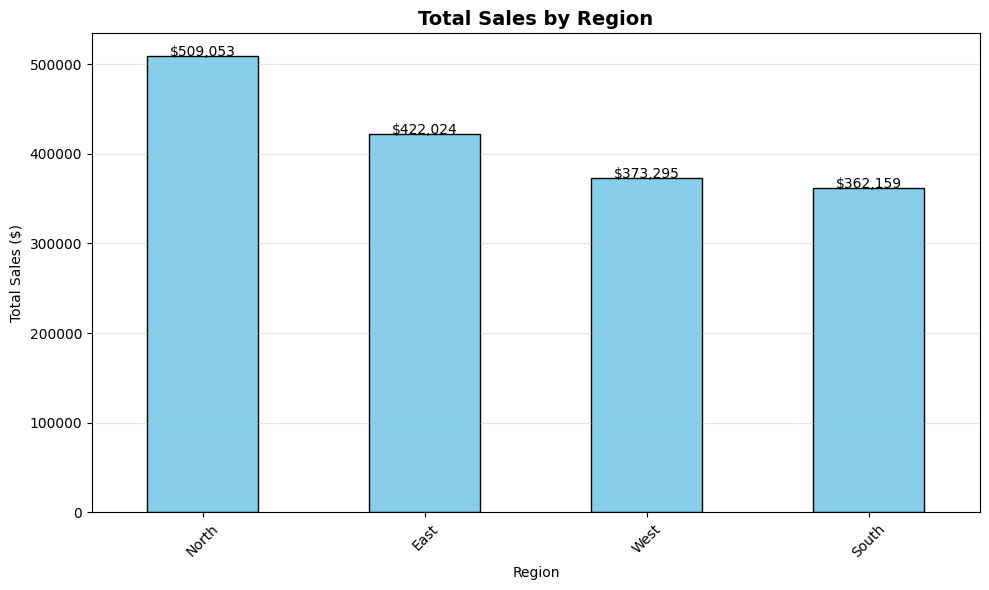

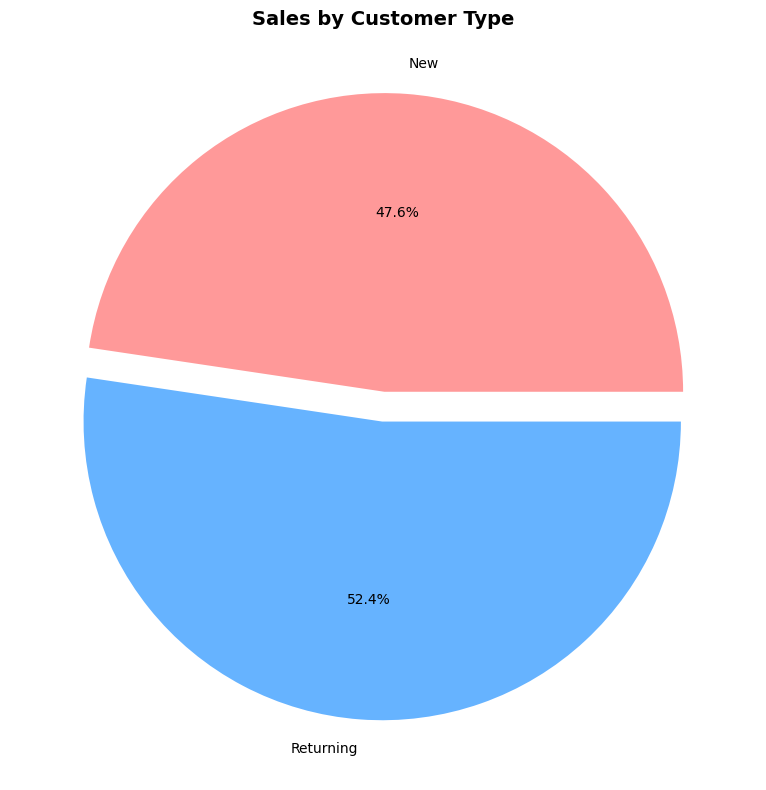

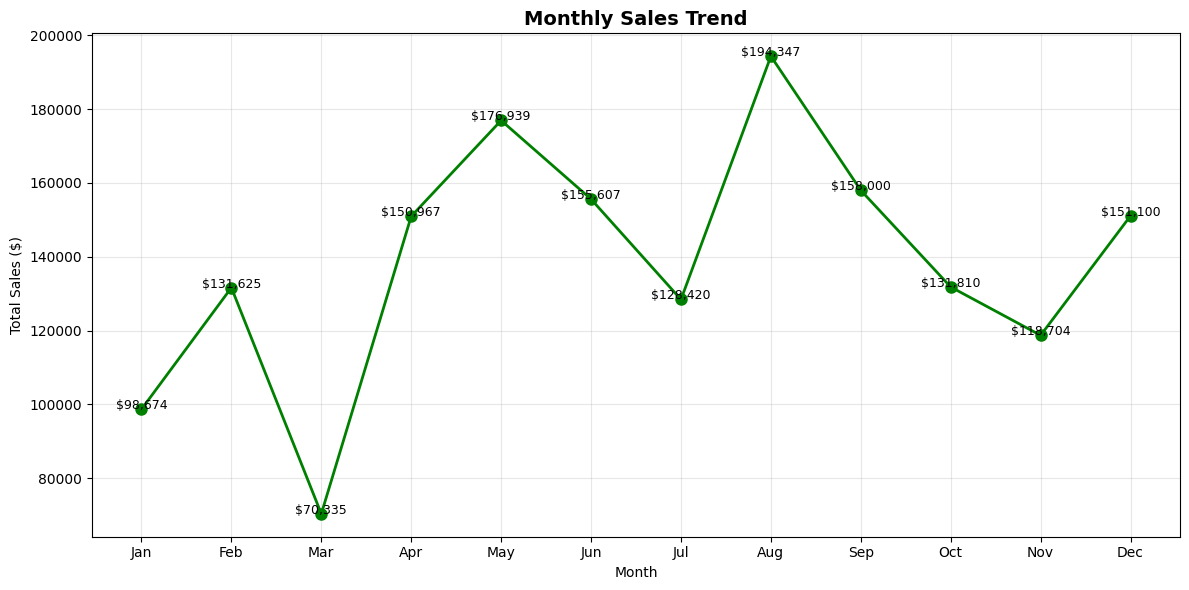

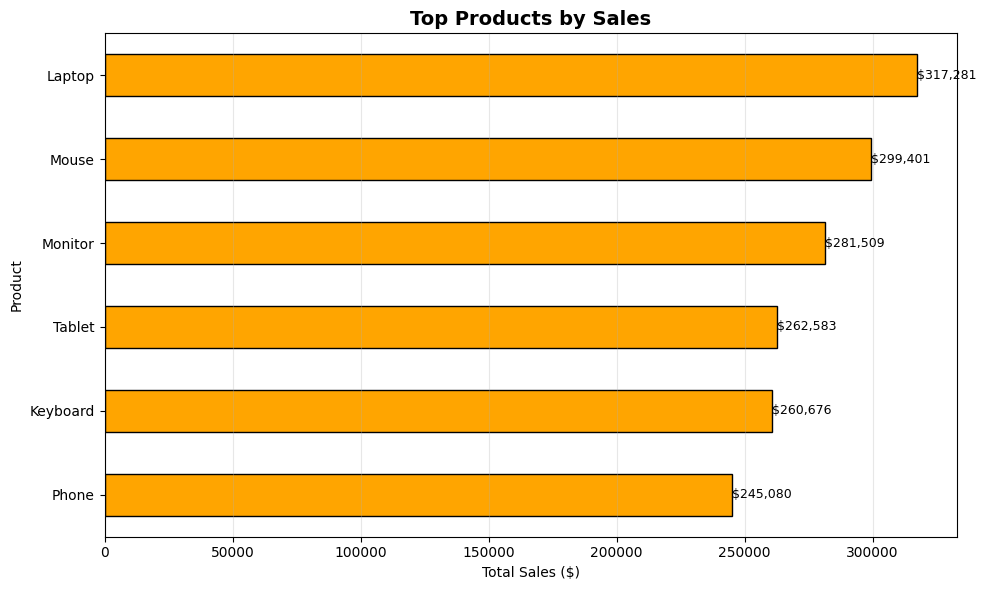

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_merged is your merged dataset
# df_merged = pd.read_csv('your_merged_file.csv')

print("=" * 60)
print("VISUALIZATIONS USING df_merged")
print("=" * 60)

# ============================================
# 1. BAR CHART - Region wise sales
# ============================================
plt.figure(figsize=(10, 6))
region_sales = df_merged.groupby('region')['sales'].sum().sort_values(ascending=False)
region_sales.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Total Sales by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(region_sales):
    plt.text(i, v + 5, f'${v:,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# ============================================
# 2. PIE CHART - Customer type distribution
# ============================================
plt.figure(figsize=(8, 8))
customer_sales = df_merged.groupby('customer_type')['sales'].sum()
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
customer_sales.plot(kind='pie', autopct='%1.1f%%', colors=colors[:len(customer_sales)], 
                   explode=[0.05]*len(customer_sales))
plt.title('Sales by Customer Type', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

# ============================================
# 3. LINE CHART - Monthly sales trend
# ============================================
plt.figure(figsize=(12, 6))
df_merged['month'] = pd.to_datetime(df_merged['date']).dt.month
monthly_sales = df_merged.groupby('month')['sales'].sum()
monthly_sales.plot(kind='line', marker='o', color='green', linewidth=2, markersize=8)
plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, alpha=0.3)
for x, y in zip(monthly_sales.index, monthly_sales.values):
    plt.text(x, y + 5, f'${y:,.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# ============================================
# 4. HORIZONTAL BAR CHART - Top products by sales
# ============================================
plt.figure(figsize=(10, 6))
product_sales = df_merged.groupby('product')['sales'].sum().sort_values(ascending=True).tail(10)
product_sales.plot(kind='barh', color='orange', edgecolor='black')
plt.title('Top Products by Sales', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.ylabel('Product')
plt.grid(axis='x', alpha=0.3)
for i, (product, sales) in enumerate(product_sales.items()):
    plt.text(sales + 5, i, f'${sales:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

<Figure size 1400x700 with 0 Axes>

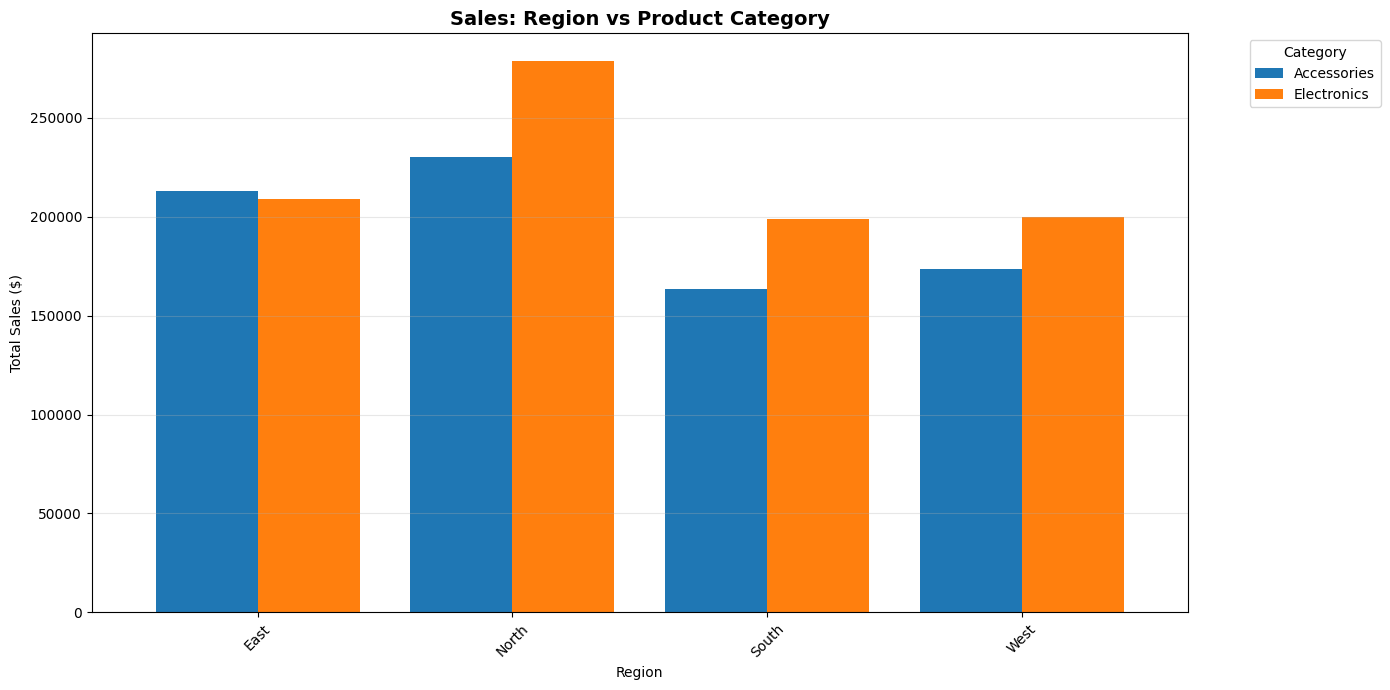

<Figure size 1200x700 with 0 Axes>

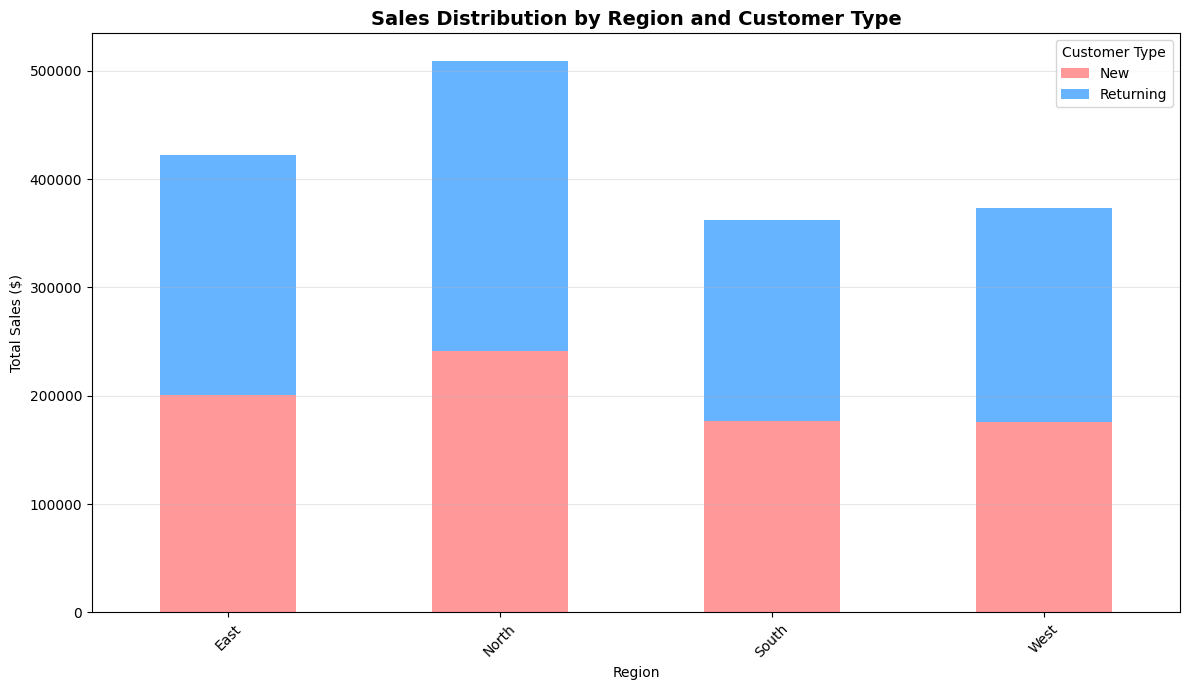

<Figure size 1200x600 with 0 Axes>

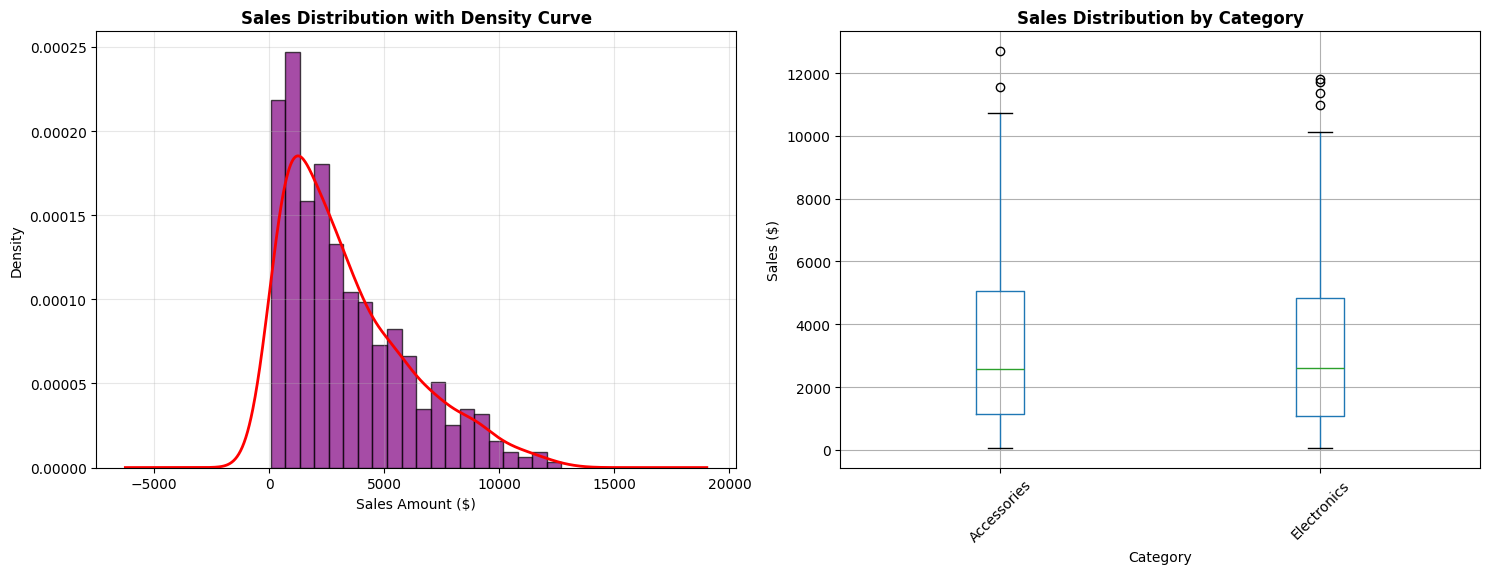

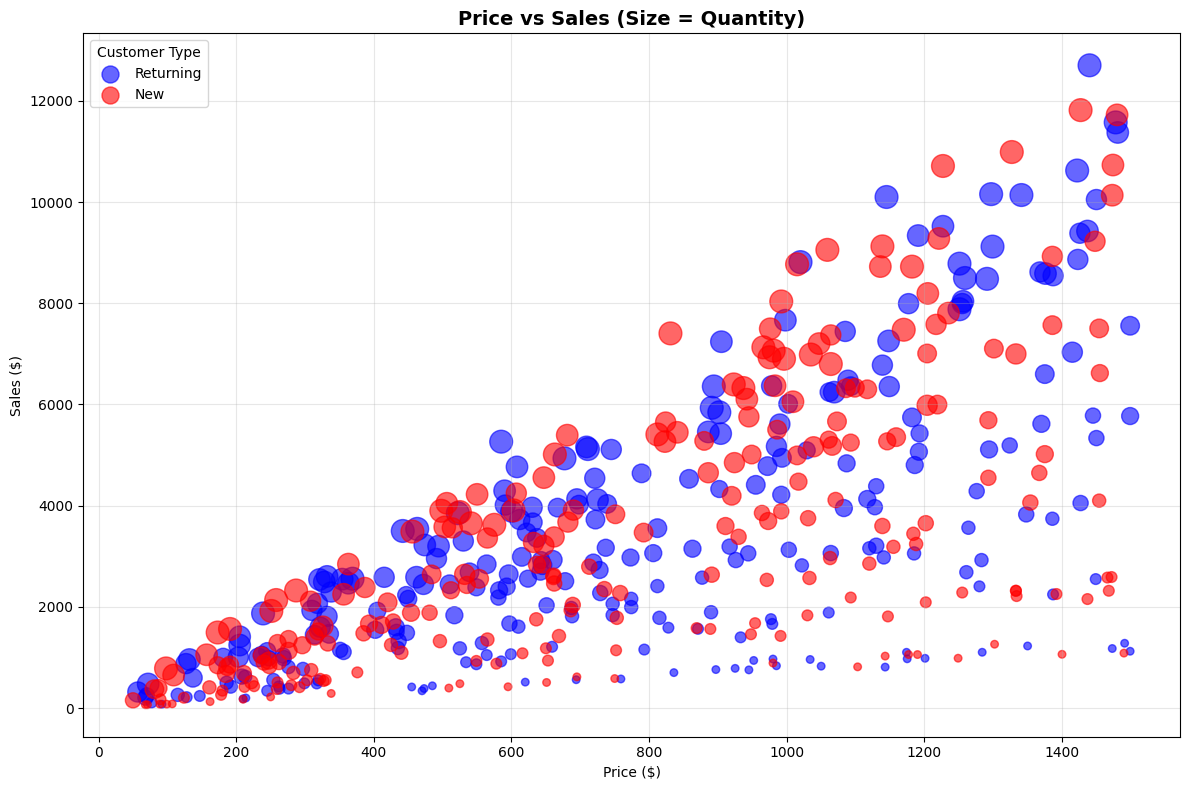

In [ ]:
# ============================================
# 5. GROUPED BAR CHART - Region vs Category
# ============================================
plt.figure(figsize=(14, 7))

pivot_region_category = pd.pivot_table(
    df_merged, 
    values='sales', 
    index='region', 
    columns='category', 
    aggfunc='sum',
    fill_value=0
)

pivot_region_category.plot(kind='bar', figsize=(14, 7), width=0.8)
plt.title('Sales: Region vs Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 6. STACKED BAR CHART - Customer type contribution by region
# ============================================
plt.figure(figsize=(12, 7))

stacked_customer = pd.pivot_table(
    df_merged,
    values='sales',
    index='region',
    columns='customer_type',
    aggfunc='sum',
    fill_value=0
)

stacked_customer.plot(kind='bar', stacked=True, figsize=(12, 7), 
                     color=['#ff9999', '#66b3ff', '#99ff99'])
plt.title('Sales Distribution by Region and Customer Type', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.legend(title='Customer Type')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 7. HISTOGRAM - Sales distribution with stats
# ============================================
plt.figure(figsize=(12, 6))

# Create two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Histogram with KDE
df_merged['sales'].plot(kind='hist', bins=20, color='purple', edgecolor='black', 
                       alpha=0.7, ax=ax1, density=True)
df_merged['sales'].plot(kind='kde', color='red', ax=ax1, linewidth=2)
ax1.set_title('Sales Distribution with Density Curve', fontsize=12, fontweight='bold')
ax1.set_xlabel('Sales Amount ($)')
ax1.set_ylabel('Density')
ax1.grid(True, alpha=0.3)

# Box plot by category
df_merged.boxplot(column='sales', by='category', ax=ax2, grid=True)
ax2.set_title('Sales Distribution by Category', fontsize=12, fontweight='bold')
ax2.set_xlabel('Category')
ax2.set_ylabel('Sales ($)')
ax2.tick_params(axis='x', rotation=45)

plt.suptitle('')  # Remove automatic title
plt.tight_layout()
plt.show()

# ============================================
# 8. SCATTER PLOT - Price vs Sales with trends
# ============================================
plt.figure(figsize=(12, 8))

# Color by customer type
colors = {'New': 'red', 'Returning': 'blue', 'Regular': 'green'}
df_merged['color'] = df_merged['customer_type'].map(colors)

# Scatter plot
for customer_type in df_merged['customer_type'].unique():
    subset = df_merged[df_merged['customer_type'] == customer_type]
    plt.scatter(subset['price'], subset['sales'], 
               s=subset['quantity']*30,  # Size by quantity
               alpha=0.6, 
               label=customer_type,
               c=colors.get(customer_type, 'gray'))

plt.title('Price vs Sales (Size = Quantity)', fontsize=14, fontweight='bold')
plt.xlabel('Price ($)')
plt.ylabel('Sales ($)')
plt.legend(title='Customer Type')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

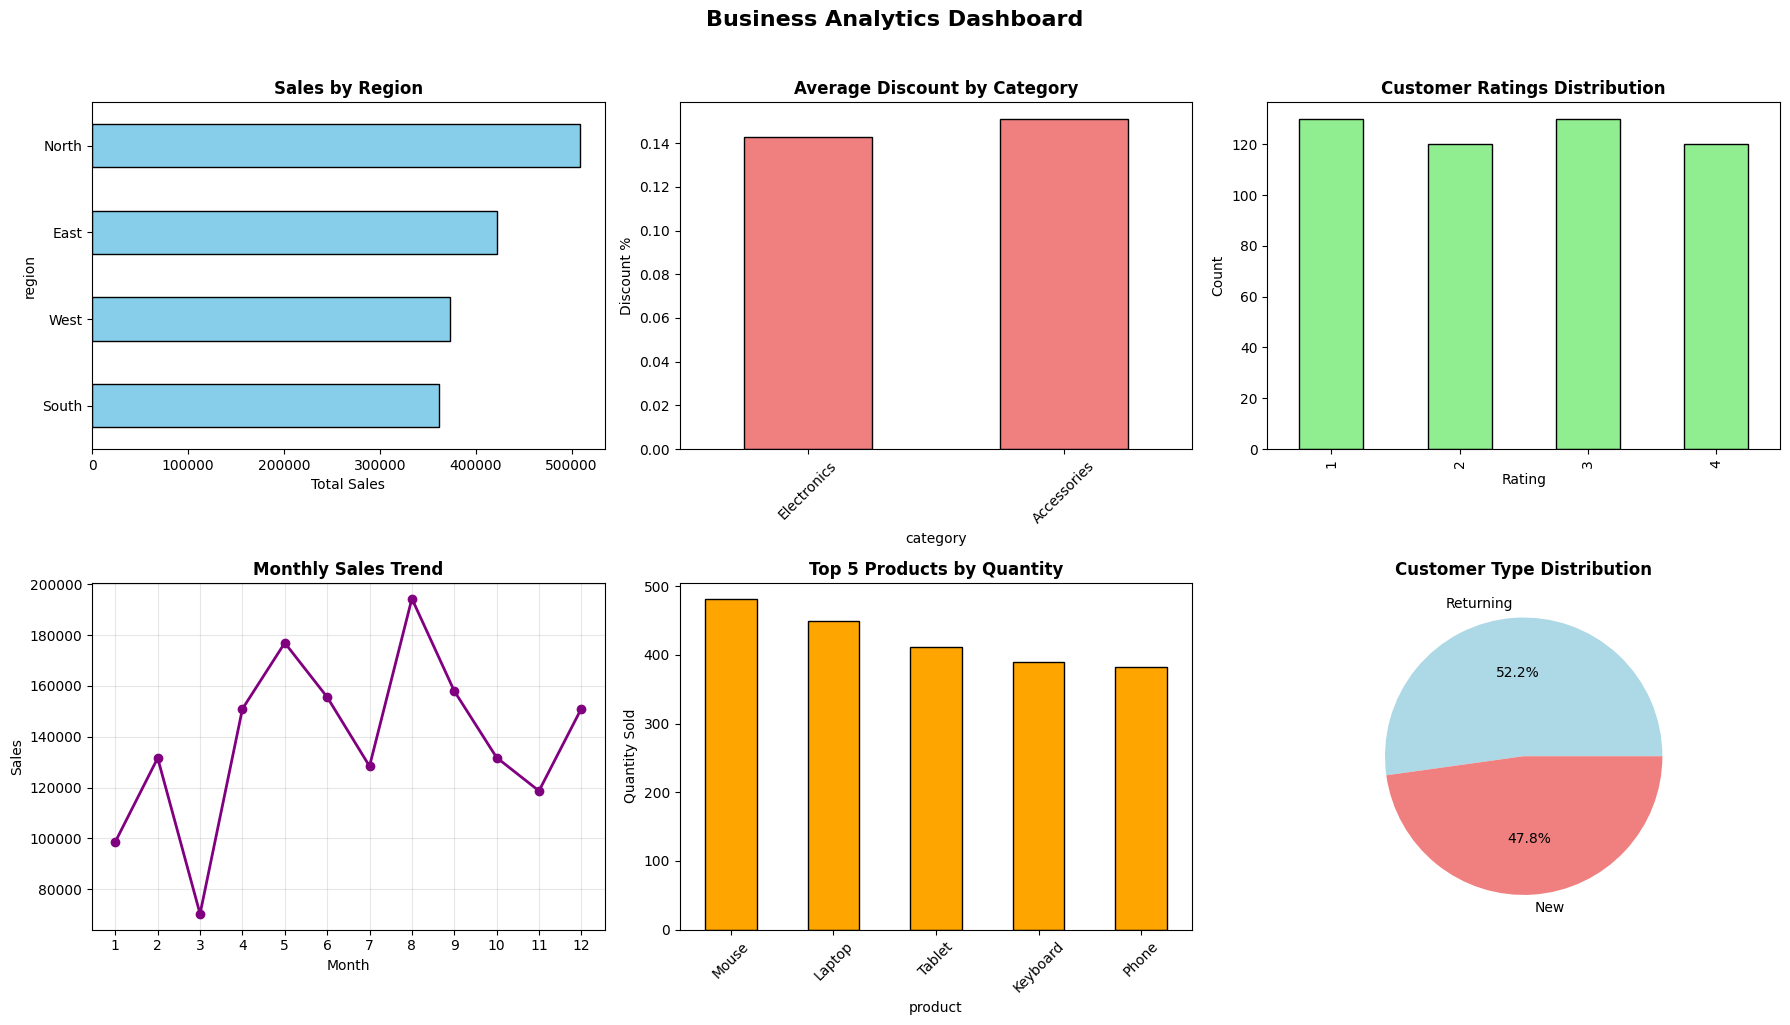

In [ ]:
# ============================================
# 9. DASHBOARD - Multiple business metrics
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Top-left: Sales by region
region_data = df_merged.groupby('region')['sales'].sum().sort_values()
region_data.plot(kind='barh', ax=axes[0,0], color='skyblue', edgecolor='black')
axes[0,0].set_title('Sales by Region', fontweight='bold')
axes[0,0].set_xlabel('Total Sales')

# 2. Top-middle: Average discount by category
discount_data = df_merged.groupby('category')['discount'].mean().sort_values()
discount_data.plot(kind='bar', ax=axes[0,1], color='lightcoral', edgecolor='black')
axes[0,1].set_title('Average Discount by Category', fontweight='bold')
axes[0,1].set_ylabel('Discount %')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Top-right: Customer ratings distribution
df_merged['customer_rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0,2], color='lightgreen', edgecolor='black')
axes[0,2].set_title('Customer Ratings Distribution', fontweight='bold')
axes[0,2].set_xlabel('Rating')
axes[0,2].set_ylabel('Count')

# 4. Bottom-left: Monthly sales trend
df_merged['month'] = pd.to_datetime(df_merged['date']).dt.month
monthly = df_merged.groupby('month')['sales'].sum()
monthly.plot(kind='line', marker='o', ax=axes[1,0], color='purple', linewidth=2)
axes[1,0].set_title('Monthly Sales Trend', fontweight='bold')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Sales')
axes[1,0].set_xticks(range(1, 13))
axes[1,0].grid(True, alpha=0.3)

# 5. Bottom-middle: Top 5 products
top_products = df_merged.groupby('product')['quantity'].sum().sort_values(ascending=False).head(5)
top_products.plot(kind='bar', ax=axes[1,1], color='orange', edgecolor='black')
axes[1,1].set_title('Top 5 Products by Quantity', fontweight='bold')
axes[1,1].set_ylabel('Quantity Sold')
axes[1,1].tick_params(axis='x', rotation=45)

# 6. Bottom-right: New vs Returning customers
customer_counts = df_merged['customer_type'].value_counts()
customer_counts.plot(kind='pie', ax=axes[1,2], autopct='%1.1f%%', 
                    colors=['lightblue', 'lightcoral'])
axes[1,2].set_title('Customer Type Distribution', fontweight='bold')
axes[1,2].set_ylabel('')

plt.suptitle('Business Analytics Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

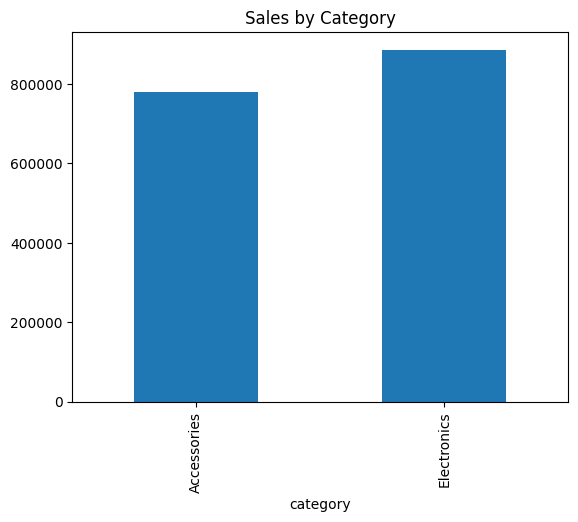

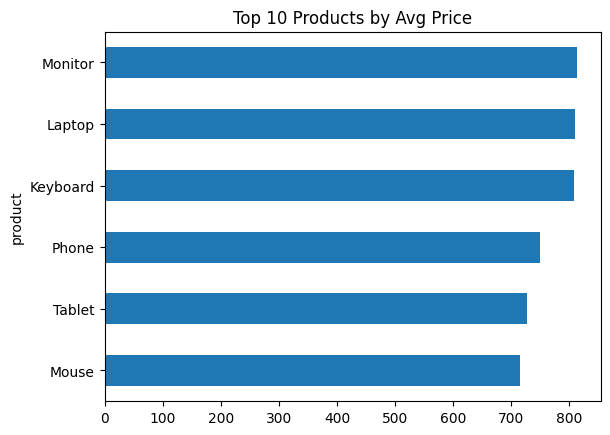

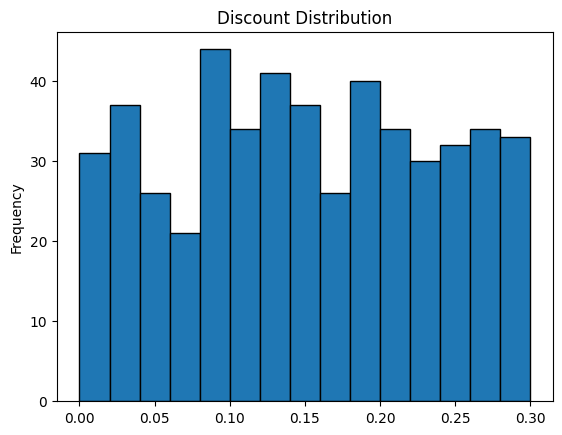

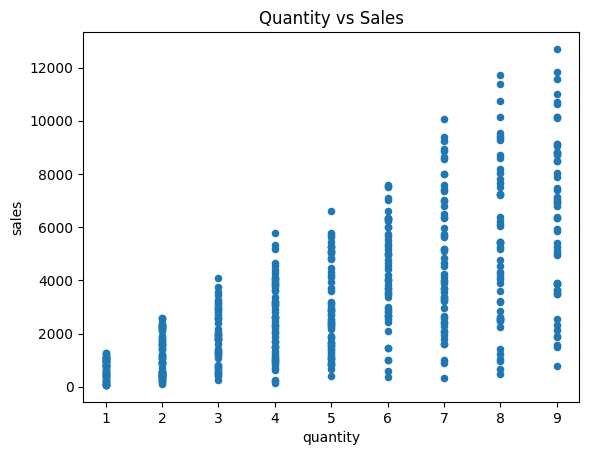

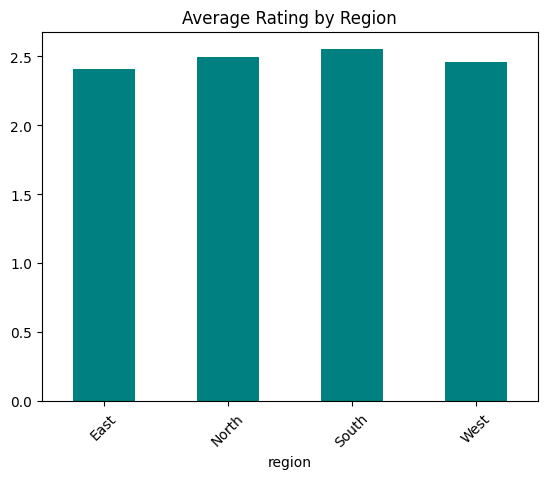

In [ ]:
# ============================================
# 10. QUICK INSIGHTS - One-liner plots
# ============================================

# Sales by category (quick bar chart)
df_merged.groupby('category')['sales'].sum().plot(kind='bar', title='Sales by Category')
plt.show()

# Average price by product (horizontal bar)
df_merged.groupby('product')['price'].mean().sort_values().tail(10).plot(kind='barh', title='Top 10 Products by Avg Price')
plt.show()

# Discount distribution
df_merged['discount'].plot(kind='hist', bins=15, title='Discount Distribution', edgecolor='black')
plt.show()

# Quantity vs Sales relationship
df_merged.plot(kind='scatter', x='quantity', y='sales', title='Quantity vs Sales')
plt.show()

# Customer ratings by region
df_merged.groupby('region')['customer_rating'].mean().plot(kind='bar', title='Average Rating by Region', color='teal')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df_merged.columns

Index(['order_id', 'date', 'region', 'product', 'category', 'customer_type',
       'quantity', 'price', 'discount', 'sales', 'customer_rating', 'month',
       'color'],
      dtype='object')

In [ ]:
df_merged.drop(columns=['discount'], inplace=True)

In [ ]:
df_merged.columns

Index(['order_id', 'date', 'region', 'product', 'category', 'customer_type',
       'quantity', 'price', 'sales', 'customer_rating', 'month', 'color'],
      dtype='object')

In [ ]:
df_merged.region.value_counts()


region
North    151
East     118
South    116
West     115
Name: count, dtype: int64

In [ ]:
df_merged.groupby('product')['sales'].sum()

product
Keyboard    260675.81
Laptop      317281.14
Monitor     281509.14
Mouse       299401.20
Phone       245079.73
Tablet      262582.76
Name: sales, dtype: float64

In [ ]:
bins=[0, 100, 500, 1000, 5000]
labels=['low', 'medium', 'high', 'very high']
df_merged['sales_category'] = pd.cut(df_merged['sales'], bins=bins, labels=labels)

In [ ]:
df_merged

,order_id,date,region,product,category,customer_type,quantity,price,sales,customer_rating,month,color,sales_category
0,1,2024-04-12,East,Laptop,Electronics,Returning,8,590,4295.20,1,4,blue,very high
1,2,2024-12-14,South,Monitor,Accessories,Returning,2,262,429.68,1,12,blue,medium
2,3,2024-09-27,North,Phone,Accessories,New,5,512,2329.60,2,9,red,very high
3,4,2024-04-16,West,Mouse,Electronics,Returning,1,485,441.35,1,4,blue,medium
4,5,2024-03-12,West,Phone,Electronics,Returning,7,332,1812.72,4,3,blue,very high
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,2024-11-20,South,Mouse,Accessories,Returning,6,314,1450.68,3,11,blue,very high
496,497,2024-01-04,North,Phone,Accessories,Returning,9,369,2557.17,4,1,blue,very high
497,498,2024-01-16,South,Keyboard,Electronics,Returning,6,722,3725.52,4,1,blue,very high
498,499,2024-10-06,North,Phone,Accessories,Returning,2,1449,2550.24,1,10,blue,very high


In [ ]:
df_merged.set_index('order_id', inplace=True)   

In [ ]:
df_merged.to_csv('merged_data.csv', index=False)

In [ ]:
df_merged

,date,region,product,category,customer_type,quantity,price,sales,customer_rating,month,color,sales_category
order_id,,,,,,,,,,,,
1,2024-04-12,East,Laptop,Electronics,Returning,8,590,4295.20,1,4,blue,very high
2,2024-12-14,South,Monitor,Accessories,Returning,2,262,429.68,1,12,blue,medium
3,2024-09-27,North,Phone,Accessories,New,5,512,2329.60,2,9,red,very high
4,2024-04-16,West,Mouse,Electronics,Returning,1,485,441.35,1,4,blue,medium
5,2024-03-12,West,Phone,Electronics,Returning,7,332,1812.72,4,3,blue,very high
...,...,...,...,...,...,...,...,...,...,...,...,...
496,2024-11-20,South,Mouse,Accessories,Returning,6,314,1450.68,3,11,blue,very high
497,2024-01-04,North,Phone,Accessories,Returning,9,369,2557.17,4,1,blue,very high
498,2024-01-16,South,Keyboard,Electronics,Returning,6,722,3725.52,4,1,blue,very high


<Axes: title={'center': 'Sales Distribution'}, ylabel='Frequency'>

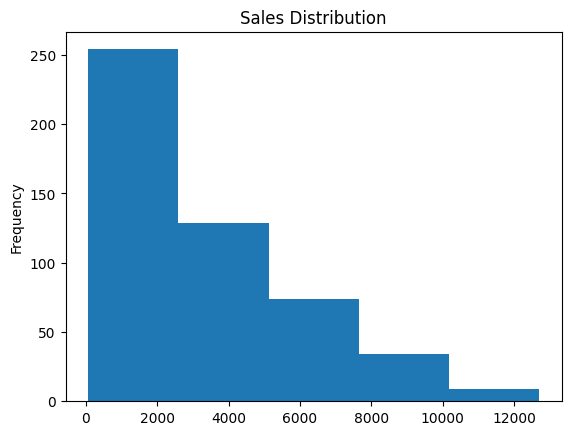

In [ ]:
df_merged['sales'].plot(kind='hist', bins=5, title='Sales Distribution')

<Axes: xlabel='product'>

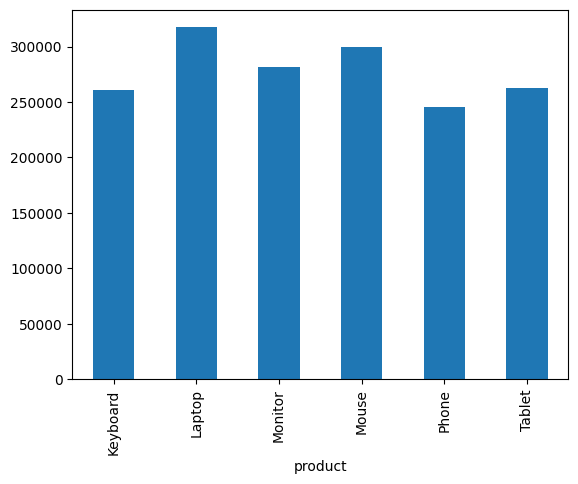

In [ ]:
df_merged.groupby('product')['sales'].sum().plot(kind='bar')